In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [30]:
df = pd.read_csv('Titanic-Dataset.csv', usecols=['Age', 'Fare', 'Survived'])

In [31]:
df.head(1)

,Survived,Age,Fare
0,0,22.0,7.25


In [32]:
df.dropna(inplace=True)

In [33]:
df.shape

(714, 3)

In [34]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [35]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [37]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [38]:
clf = DecisionTreeClassifier()

In [39]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [40]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [41]:
np.mean(cross_val_score(DecisionTreeClassifier(), X,y,cv=10, scoring='accuracy'))

np.float64(0.6275234741784037)

In [42]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal',strategy='quantile')

In [43]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [44]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

C:\Users\MY PC\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\MY PC\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [45]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [46]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [47]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1],
})

In [48]:
output['age_labels']=pd.cut(x=X_train['Age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels']=pd.cut(x=X_train['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [49]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
345,24.0,5.0,13.0000,6.0,"(23.0, 25.0]","(10.5, 13.0]"
1,38.0,11.0,71.2833,12.0,"(35.0, 38.0]","(51.479, 76.292]"
265,36.0,10.0,10.5000,5.0,"(35.0, 38.0]","(8.158, 10.5]"
806,39.0,11.0,0.0000,0.0,"(38.0, 42.0]",NaN
599,49.0,13.0,56.9292,12.0,"(47.0, 54.0]","(51.479, 76.292]"


In [50]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [51]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [52]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X,y,cv=10, scoring='accuracy'))

C:\Users\MY PC\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\MY PC\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6317097026604068)

In [53]:
def discretize(bins, strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins, encode='ordinal',strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins, encode='ordinal',strategy=strategy)
    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X,y,cv=10, scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,0], color='red')
    plt.title('After')

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,1], color='red')
    plt.title('Fare')

    plt.show()




0.6345266040688575


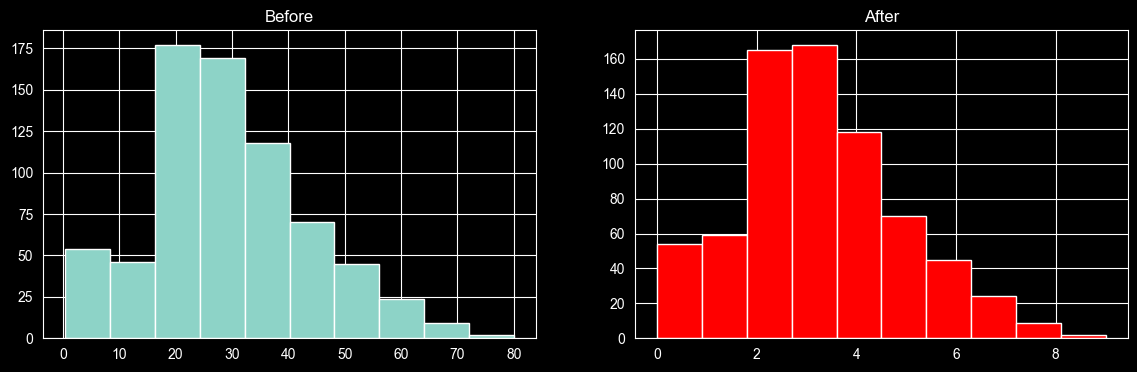

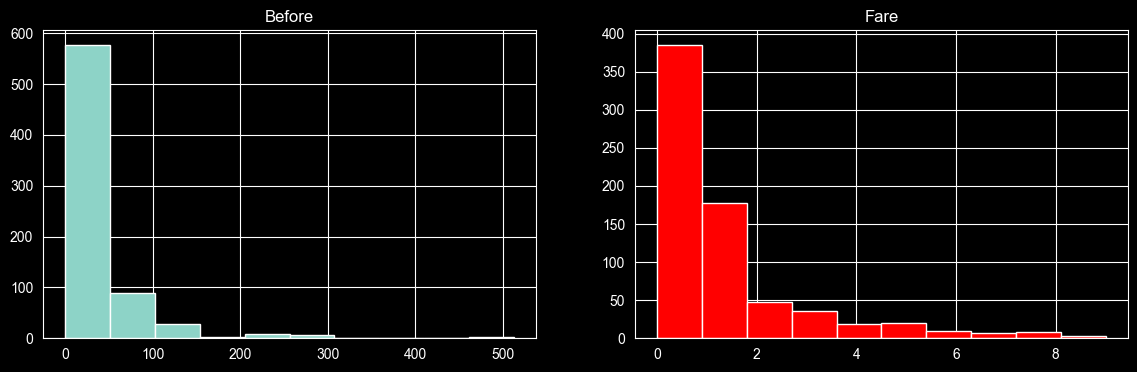

In [54]:
discretize(10,'kmeans')

In [55]:
data = pd.read_csv('Titanic-Dataset.csv')

In [56]:
data.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
